# Imports

In [1]:
import warnings
import logging
logging.getLogger('PyNN').setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")
from numba import njit
import numpy as np
import timeit
import pyNN.nest as sim
import matplotlib.pyplot as plt
from pyNN.utility import ProgressBar
from dataclasses import dataclass
import time
from tqdm import tqdm
from joblib import Parallel, delayed
import pickle 




              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Aug 27 2024 04:33:52

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# Spike sequence generation functions

In [2]:
@njit
def generate_random_sequence_spike_duration_constraint(sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[int], int]:
    """
        Generates a random list of spike timings

        Parameters
        ----------
        sequence_length : int
            maximum number of timings in the sequence
        min_time_interval : int
            minimum time interval between two successive timings
        max_time_interval : int
            maximum time interval between two successive timings
        period_length : int
            duration of the sequence (maximum timing in the sequence)

        Returns
        -------
        list_time_spike : list[int]
            list of spike timings
        int
            number of spikes in the sequence
        
    """
    time_spike = 0
    list_time_spike = np.zeros(sequence_length, dtype=np.int32)
    for i in range(sequence_length): 
        # the following timing is chosen as last timing plus a random integer between min_time_interval and max_time_interval
        time_spike = time_spike + np.random.randint(min_time_interval,max_time_interval)
        # we do not consider timings greater than period_length 
        if time_spike<period_length :
            list_time_spike[i] = time_spike
        else:
            return list_time_spike, i
    return list_time_spike, sequence_length

@njit
def input_spike_timing_multiple_periods_signal_generator(signal_spike_timings : list[int], num_spike_sequence : int, first_spike_time : int, num_periods : int, period_length : int) -> list[int]:
    """
        Generates a periodic sequence of spike timings based on a sequence of spike timings 

        Parameters
        ----------
        signal_spike_timings : list[int]
            list of spike timings
        num_spike_sequence : int
            number of spikes in the sequence
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods of the signal 
        period_length : int
            duration of the period

        Returns
        -------
        spike_timing_list : list[int]
            list of spike timings
    """
    spike_timing_list = np.zeros(num_periods*num_spike_sequence, dtype=np.int32)
    for i in range(num_periods):
        for j in range(num_spike_sequence):
            spike_timing_list[i*num_spike_sequence+j] = first_spike_time+period_length*i+signal_spike_timings[j]
    return spike_timing_list


@njit
def generate_multiple_random_sequence_spike_duration_constraint(num_sequence : int, sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generates a pattern of spike timings for several neurons. Each element of the output list corresponds to the spike timings for one neuron.

        Parameters
        ----------
        num_sequence : int
            number of random list to generate (or number of spiking neurons)
        sequence_length : int
            maximum number of timings in each sequence
        min_time_interval : int
            minimum time interval between two successive timings in each sequence
        max_time_interval : int
            maximum time interval between two successive timings in each sequence
        period_length : int
            duration of all sequences (maximum timing in each sequence)

        Returns
        -------
        list_time_spike : list[list[int]]
            list of list of spike timings (length equal to num_sequence)
        num_spike_sequence_list
            list of number of spikes in each sequence
    """
    spike_sequence_list = np.zeros((num_sequence, sequence_length), dtype=np.int32)
    num_spike_sequence_list = np.zeros(num_sequence, dtype=np.int32)
    for i in range(num_sequence):
        # generate one sequence of random numbers
        spike_sequence, num_spike_sequence = generate_random_sequence_spike_duration_constraint(sequence_length, min_time_interval, max_time_interval, period_length)
        spike_sequence_list[i] = spike_sequence
        num_spike_sequence_list[i] = num_spike_sequence
    return spike_sequence_list, num_spike_sequence_list

@njit
def generate_multiple_random_sequence_multiple_neurons_spike_duration_constraint(num_patterns : int, num_sequence : int, sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[list[list[int]]], list[list[int]]]:
    """
        Generates multiple pattern of spike timings for several neurons. Each element of the output list corresponds to a pattern of spike timings for multiple neurons.

        Parameters
        ----------
        num_patterns : int
            number of random pattern to generate
        num_sequence : int
            number of random list to generate for one pattern (or number of spiking neurons)
        sequence_length : int
            maximum number of timings in each sequence of a pattern
        min_time_interval : int
            minimum time interval between two successive timings in each sequence of a pattern
        max_time_interval : int
            maximum time interval between two successive timings in each sequence of a pattern
        period_length : int
            duration of all sequences (maximum timing in each sequence) of a pattern

        Returns
        -------
        list_time_spike : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        num_spike_sequence_list : list[list[int]]
            list of list of number of spikes in each sequence of each pattern
    """
    signal_spike_timings_list = np.zeros((num_patterns, num_sequence, sequence_length), dtype=np.int32)
    num_spike_sequence_list = np.zeros((num_patterns, num_sequence), dtype=np.int32)
    for i in range(num_patterns):
        signal_spike_timings_list_i, num_spike_sequence_list_i = generate_multiple_random_sequence_spike_duration_constraint(num_sequence,sequence_length,min_time_interval,max_time_interval,period_length)
        signal_spike_timings_list[i] = signal_spike_timings_list_i
        num_spike_sequence_list[i] = num_spike_sequence_list_i
    return signal_spike_timings_list, num_spike_sequence_list

@njit
def multiple_input_spike_timing_multiple_periods_signal_generator(signal_spike_timings_list : list[list[int]], num_spike_sequence_list : list[int], first_spike_time : int, num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generates a periodic sequence of spike timings for multiple neurons based on a pattern of spike timings for several neurons. 

        Parameters
        ----------
        signal_spike_timings_list : list[list[int]]
            list of list of spike timings
        num_spike_sequence_list : list[int]
            list of number of spikes for each neuron
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods of the signal 
        period_length : int
            duration of the period

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings
        spike_num_list : list[int]
            list of number of spike in the signal for each neuron
    """
    num_neuron = len(signal_spike_timings_list)
    sequence_length = len(signal_spike_timings_list[0])
    spike_timing_matrix = np.zeros((num_neuron, sequence_length*num_periods),  dtype=np.int32)
    spike_num_list = np.zeros(num_neuron,  dtype=np.int32)
    for i in range(num_neuron):
        signal_spike_timings = signal_spike_timings_list[i]
        num_spike_sequence = num_spike_sequence_list[i]
        # generate a periodic sequence of spikes for each sequence of the list signal_spike_timings_list
        spike_timing_list = input_spike_timing_multiple_periods_signal_generator(signal_spike_timings, int(num_spike_sequence), first_spike_time, num_periods, period_length)
        spike_num = len(spike_timing_list)
        spike_timing_matrix[i, :spike_num] = spike_timing_list 
        spike_num_list[i] = spike_num
    return spike_timing_matrix, spike_num_list

@njit
def multiple_input_spike_timing_multiple_periods_multiple_signal_generator(multiple_signal_spike_timings_list : list[list[list[int]]], multiple_signal_num_spike_sequence_list : list[list[int]],  first_spike_time : int, num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generate a sequence of spike timings consisting of successive periodic sequences of spike timings for multiple neurons, each periodic sequence being based on a list of sequences of spike timings.
        For instance if a list composed of two sequences of spike, the function will return a sequence in wich the first sequence will be repeated num_periods times, followed by the second sequence repeated num_periods times.

        Parameters
        ----------
        multiple_signal_spike_timings_list : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods for each sequence of the signal 
        period_length : int
            duration of the period for each sequence of the signal

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings (each element is the spike timings for one neuron)
        last_spike_index : list[int]
            list of number of spike in the signal for each neuron
    """
    num_pattern = len(multiple_signal_spike_timings_list)
    num_neuron = len(multiple_signal_spike_timings_list[0])
    sequence_length = len(multiple_signal_spike_timings_list[0][0])
    spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    last_spike_index = np.zeros(num_neuron, dtype=np.int32)
    for i in range(num_pattern):
        # for each pattern, generate a periodic signal from this pattern, and then concatenate the signals
        spike_timing_matrix_i, spike_num_list = multiple_input_spike_timing_multiple_periods_signal_generator(multiple_signal_spike_timings_list[i], multiple_signal_num_spike_sequence_list[i], first_spike_time+i*(period_length*num_periods), num_periods, period_length) 
        for j in range(num_neuron):
            num_spike_j = int(spike_num_list[j])
            new_last_index = last_spike_index[j] + num_spike_j
            spike_timing_matrix[j, int(last_spike_index[j]):int(new_last_index)] = spike_timing_matrix_i[j,:num_spike_j]
            last_spike_index[j] = new_last_index
    return spike_timing_matrix, last_spike_index

@njit
def multiple_superimposed_input_spike_timing_multiple_signal_generator(multiple_signal_spike_timings_list : list[list[list[int]]], multiple_signal_num_spike_sequence_list : list[list[int]],  first_spike_time_list : list[int], num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generate a sequence of spike timings consisting of successive periodic sequences of spike timings for multiple neurons, each periodic sequence being based on a list of sequences of spike timings.
        For instance if a list composed of two sequences of spike, the function will return a sequence in wich the first sequence will be repeated num_periods times, followed by the second sequence repeated num_periods times.

        Parameters
        ----------
        multiple_signal_spike_timings_list : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        first_spike_time_list : list[int]
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods for each sequence of the signal 
        period_length : int
            duration of the period for each sequence of the signal

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings (each element is the spike timings for one neuron)
        last_spike_index : list[int]
            list of number of spike in the signal for each neuron
    """
    num_pattern = len(multiple_signal_spike_timings_list)
    num_neuron = len(multiple_signal_spike_timings_list[0])
    sequence_length = len(multiple_signal_spike_timings_list[0][0])
    spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    last_spike_index = np.zeros(num_neuron, dtype=np.int32)
    sorted_spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    for i in range(num_pattern):
        # for each pattern, generate a periodic signal from this pattern, and then concatenate the signals
        spike_timing_matrix_i, spike_num_list = multiple_input_spike_timing_multiple_periods_signal_generator(multiple_signal_spike_timings_list[i], multiple_signal_num_spike_sequence_list[i], first_spike_time_list[i], num_periods, period_length) 
        for j in range(num_neuron):
            num_spike_j = int(spike_num_list[j])
            new_last_index = last_spike_index[j] + num_spike_j
            spike_timing_matrix[j, int(last_spike_index[j]):int(new_last_index)] = spike_timing_matrix_i[j,:num_spike_j]
            last_spike_index[j] = new_last_index
            if i == num_pattern-1:
                sorted_spike_timing_matrix[j, :int(new_last_index)] = np.sort(spike_timing_matrix[j, :int(new_last_index)])
    return sorted_spike_timing_matrix, last_spike_index

In [3]:
a,b = generate_multiple_random_sequence_multiple_neurons_spike_duration_constraint(2,5,10,3,10,30)
c,d  = multiple_superimposed_input_spike_timing_multiple_signal_generator(a,b,[10*(i+1) for i in range(2)], 1,30)
print(a)
print(c)

[[[ 4  7 15 19 27  0  0  0  0  0]
  [ 6 10 16 22 28  0  0  0  0  0]
  [ 5 12 20 28  0  0  0  0  0  0]
  [ 5  8 15 23  0  0  0  0  0  0]
  [ 5 12 20 24  0  0  0  0  0  0]]

 [[ 6 12 15 20 26  0  0  0  0  0]
  [ 7 12 17 22 29  0  0  0  0  0]
  [ 3 11 20 23  0  0  0  0  0  0]
  [ 3  7 14 20 23  0  0  0  0  0]
  [ 9 18 24  0  0  0  0  0  0  0]]]
[[14 17 25 26 29 32 35 37 40 46  0  0  0  0  0  0  0  0  0  0]
 [16 20 26 27 32 32 37 38 42 49  0  0  0  0  0  0  0  0  0  0]
 [15 22 23 30 31 38 40 43  0  0  0  0  0  0  0  0  0  0  0  0]
 [15 18 23 25 27 33 34 40 43  0  0  0  0  0  0  0  0  0  0  0]
 [15 22 29 30 34 38 44  0  0  0  0  0  0  0  0  0  0  0  0  0]]


# Spiking Neural Network Class

### Progress bar for pyNN simulation

In [4]:
class MyProgressBar(object):
    """
    A callback which draws a progress bar in the terminal.
    """
    
    def __init__(self, interval, t_stop):
        self.interval = interval
        self.t_stop = t_stop
        self.pb = ProgressBar(width=int(t_stop / interval), char=".")
        
    def __call__(self, t):
        self.pb(t / self.t_stop)
        return t + self.interval

### Function to create connections of the pattern recognition network based on a pattern of spike

In [5]:
@njit
def syn_weight_delay_from_spike_timings(period_length : int, num_interval : int, signal_spike_timings_list : list[list[list[int]]], index_last_spike_timings_list : list[list[int]],  synaptic_weight : int, sequence_weight_factor : int, pattern_num : int) -> tuple[int, int, list[list[float]], list[list[float]]]:
    
    """
        Creates a set of weights and delays to construct a pattern recognition SNN

        Parameters
        ----------
        period_length : int
            period length of the signals
        num_interval : int
            number of interval to divide the period of the signals (or number of output neurons for each learned signal)
        signal_spike_timings_list : list[list[list[int]]]
            patterns of spike timings used to construct the network
        index_last_spike_timings_list : list[list[int]]
            list giving for each pattern in signal_spike_timings_list the number of spikes for each neuron
        synaptic_weight : int
            synaptic weight necessary for generating one spike from one input spike
        sequence_weight_factor : int
            ratio of output-output synaptic weight to input-output synaptic weight
        pattern_num : int
            index of the pattern to recognize in the list signal_spike_timings_list
        
        Returns
        -------
        num_neuron_input : int
            number of input neurons in the network
        num_neuron_output : int
            number of output neurons in the network
        input_output_syn_weight_delay_list : list[list[float]]
            list of connections from input to output neurons, each element of the list is a 4 elements list 
            [input neuron id of input population, output neuron id of output population, synaptic weight, synaptic delay]
        output_output_syn_weight_delay_list : list[list[float]]
            list of connections from output to output neurons, each element of the list is a 4 elements list
            [input neuron id of output population, output neuron id of output population, synaptic weight, synaptic delay]
    """
    # time length of each sub interval of the sequence period  
    time_interval_length = int(period_length // num_interval)
    # number of input neurons in the sequence
    num_sequence = len(signal_spike_timings_list[pattern_num])
    #list of connections from input to output neurons
    length_output_list = np.sum(index_last_spike_timings_list[pattern_num])
    input_output_syn_weight_delay_list = np.empty((int(length_output_list),4), dtype = np.float32)
    #list to count the number of input to output connection
    counter_list = np.zeros(num_interval)
    # create connections from each input neuron to the output neurons 
    list_index_incr = 0 
    for i in range(num_sequence):
        num_spike_i = int(index_last_spike_timings_list[pattern_num][i])
        for j in range(num_spike_i):
        # create a connection for each spike of an input neuron
            spike_timing = int(signal_spike_timings_list[pattern_num][i][j])
            # the output neuron is selected depending on the timing of the spike 
            output_neuron = spike_timing // time_interval_length
            # the synaptic delay is chosen depending on the timing of a spike with respect to the time interval in which it occurs
            synaptic_delay = time_interval_length - spike_timing % time_interval_length
            # create a connection tuple with default weight (1 input spike generates 1 output spike), the weight value will be reduced after based on the number of input to output connections
            input_output_syn_weight_delay_list[list_index_incr, 0] = i
            input_output_syn_weight_delay_list[list_index_incr, 1] = output_neuron
            input_output_syn_weight_delay_list[list_index_incr, 2] = synaptic_weight
            input_output_syn_weight_delay_list[list_index_incr, 3] = synaptic_delay
            # increment the connection to output_neuron counter
            counter_list[output_neuron] += 1
            list_index_incr +=1
    
    # define first output neuron having non zero connection
    first_neuron = 0            
    while counter_list[first_neuron] == 0:
        first_neuron+=1
    # update weights based on the number of connections to each output neurons, so that output neuron fires only if all input spike arrive synchronously
    num_connections = len(input_output_syn_weight_delay_list)
    for i in range(num_connections):
        # if the output neuron is the first of a sequence to spike, then we divide the weight by the number of connections
        if input_output_syn_weight_delay_list[i,1] == first_neuron:
            new_weight = input_output_syn_weight_delay_list[i,2] / counter_list[int(input_output_syn_weight_delay_list[i][1])]
        # if the output neuron is not the first of a sequence to spike, then we divide the weight by the number of connections plus the output to output connection which relative weight is given by the variable sequence_weight_force
        else:
            new_weight = input_output_syn_weight_delay_list[i,2] / (sequence_weight_factor+counter_list[int(input_output_syn_weight_delay_list[i][1])])
        #replace connection weight
        input_output_syn_weight_delay_list[i,2] = new_weight
    # create connections from the output neurons to the output neurons
    
    output_output_syn_weight_delay_list = np.empty((num_interval-1-first_neuron,4), dtype = np.float32)
    # iterate over the output neurons
    for i in range(first_neuron, num_interval-1):
        # presynaptic neuron
        pre_neuron = i
        # postsynaptic neuron
        post_neuron= i+1
        # for all other neuron of the sequence the weight is similar to that of input to output connections with a factor self.args.sequence_weight_factor to avoid neurons from spiking outside of a sequence
        weight = sequence_weight_factor*synaptic_weight / (sequence_weight_factor+counter_list[post_neuron])
        # the delay is given by the length of a time subdivision of the signal period. The -1 compensates for the time generation of a spike by the neuron
        syn_delay = time_interval_length-1
        output_output_syn_weight_delay_list[i-first_neuron,0] = pre_neuron
        output_output_syn_weight_delay_list[i-first_neuron,1] = post_neuron
        output_output_syn_weight_delay_list[i-first_neuron,2] = weight
        output_output_syn_weight_delay_list[i-first_neuron,3] = syn_delay
    num_neuron_input = num_sequence
    num_neuron_output = num_interval
    return num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list, output_output_syn_weight_delay_list

### Class to create a pattern recognition network, simulate and analyse its results

In [6]:
class Multiple_Neuron_Pattern_Detector():
    """
    A class to create and simulate a pattern detection SNN

    Attributes
    ----------
    args : dataclass Params
        parameters for creating and simulating the SNN:
            num_interval : int                    
                number of interval to divide the period of the signals (or number of output neurons for each learned signal)
            period_length : float                  
                length of the period of the signals
            synaptic_weight : float                
                synaptic weight necessary for generating one spike from one input spike
            signal_spike_timings_list : list                            
                patterns of spike timings used to construct the network
            timestep : float                       
                timestep of the simulation
            simulation_duration : float    
                duration of the simulation
            verbose : bool                         
                displays more verbose output
            sequence_weight_factor : int  
                ratio of output-output synaptic weight to input-output synaptic weight

    Methods
    -------
    build(sim, multiple_input_spike_timing_list)
        Creates a SNN to recognize several sequences of spike
    add_spike_signal_single_neuron(sim, pop_name, neuron_id, spike_times, spike_weight)
        Adds a sequence of input spike to a single neuron
    syn_weight_delay_from_spike_timings(pattern_num)
        Creates a set of weights and delays to construct a pattern recognition SNN
    run(sim, input_spike_timing_list)
        Creates and simulate a pattern detection SNN
   """

    def __init__(self, args):
        """
        Parameters
        ----------
        args : dataclass Params
            parameters for creating and simulating the SNN:
                num_interval : int                    
                    number of interval to divide the period of the signals (or number of output neurons for each learned signal)
                period_length : float                  
                    length of the period of the signals
                synaptic_weight : float                
                    synaptic weight necessary for generating one spike from one input spike
                signal_spike_timings_list : list                            
                    patterns of spike timings used to construct the network
                timestep : float                       
                    timestep of the simulation
                simulation_duration : float    
                    duration of the simulation
                verbose : bool                         
                    Displays more verbose output.
        """
        self.args : Params = args


    def build(self, sim, multiple_input_spike_timing_list, last_spike_index_list):
        """
            Creates a SNN to recognize several sequences of spike. The network structured is created based on args.signal_spike_timings_list

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            multiple_input_spike_timing_list : list[list[list[int]]]
                input signal to the network
        """
        print('build start')
        # get number of input neurons from one of the patterns to create the input population 
        num_neuron_input, _, _, _ = self.syn_weight_delay_from_spike_timings_class_function(pattern_num=0)
        start = time.time()
        ###---POPULATIONS OF THE NETWORK-------------------------------------------------------
        self.pops = {}

        ###---CELL PARAMETERS-------------------------------------------------------------------------------
        
        v_init=-65.0      #initial membrane potential of the neurons
        tau_m = 1.0       #membrane time constant of the neurons (here for fast dynamic neuron)
        tau_refrac = 1  #refractory time of the neurons, we chose a relatively long time to avoid excessive spiking of neurons (no inhibition in this network)
        cell_initial_values = {
                'v' : v_init
                }
        tau_refrac_output = 0.5

        # Input excitatory neurons
        self.pops['input'] = sim.Population(num_neuron_input, sim.IF_curr_alpha(tau_m=tau_m, tau_refrac=tau_refrac), 
                                        initial_values=cell_initial_values, label="input")
        # Record only spike here, for faster code
        #self.pops['input'].record(['spikes'])

        # Number of pattern to recognize
        tot_pattern = len(self.args.signal_spike_timings_list)

        # Create output neurons and synapses to recognize each pattern 
        ###---PROJECTIONS OF THE NETWORK---------------------------------------------------
        self.projs = {}
        for pattern_num in range(tot_pattern):
            # Get network parameters for recognition of the pattern
            num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list, output_output_syn_weight_delay_list = self.syn_weight_delay_from_spike_timings_class_function(pattern_num=pattern_num)
            
            # Create output neurons
            self.pops['output'+str(pattern_num)] = sim.Population(num_neuron_output, sim.IF_curr_alpha(tau_m=tau_m, tau_refrac=tau_refrac_output), 
                                            initial_values=cell_initial_values, label="output"+str(pattern_num))
            # Record only spike here, for faster code
            self.pops['output'+str(pattern_num)].record(['spikes'])

            # Static synapse, no learning here
            syn = sim.StaticSynapse()
            # Connect input neurons to output neurons from the list input_output_syn_weight_delay_list 
            connector_in_out = sim.FromListConnector(input_output_syn_weight_delay_list, column_names=["weight", "delay"])
            self.projs['in_out'+str(pattern_num)] = sim.Projection(self.pops['input'], self.pops['output'+str(pattern_num)], connector_in_out, syn, receptor_type='excitatory', label="in_out_connections"+str(pattern_num))
            # Connect output neurons to output neurons from the list output_output_syn_weight_delay_list
            connector_out_out = sim.FromListConnector(output_output_syn_weight_delay_list, column_names=["weight", "delay"])
            self.projs['out_out'+str(pattern_num)] = sim.Projection(self.pops['output'+str(pattern_num)], self.pops['output'+str(pattern_num)], connector_out_out, syn, receptor_type='excitatory', label="out_out_connections"+str(pattern_num))

        # Add input spike to input neuron from the list multiple_input_spike_timing_list
        for i in range(num_neuron_input):
            num_spike_neuron_i = last_spike_index_list[i]
            input_spike_timing_list = multiple_input_spike_timing_list[i][:num_spike_neuron_i]
            self.add_spike_signal_single_neuron(sim, 'input', i, input_spike_timing_list, self.args.synaptic_weight)

        end = time.time()
        if self.args.verbose: print(f'build step: {end-start:.3f}')
    

    def add_spike_signal_single_neuron(self, sim, pop_name, neuron_id, spike_times, spike_weight):
        """
            Adds a sequence of input spike to a single neuron of a population

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            pop_name : string
                name of the population 
            neuron_id : int
                id of the neuron to which we input a sequence of spikes
            spike_times : list[int]
                list of input spike times 
            spike_weight : float
                synaptic weight necessary for generating one spike from one input spike
                
        """
        # Create a spiking population of one neuron
        input_spike = sim.Population(1, sim.SpikeSourceArray(spike_times=spike_times), label="input spike")
        # Connect the spiking population to the neuron
        syn_spike_input = sim.StaticSynapse(weight=spike_weight)                    
        connections_input_stim_neuron = sim.Projection(input_spike, self.pops[pop_name][neuron_id:neuron_id+1], sim.FixedNumberPreConnector(1), syn_spike_input, receptor_type='excitatory')


    def syn_weight_delay_from_spike_timings_class_function(self, pattern_num):
        """
            Creates a set of weights and delays to construct a pattern recognition SNN

            Parameters
            ----------
            pattern_num : int
                index of the pattern to recognize in the list signal_spike_timings_list
            
            Returns
            -------
            num_neuron_input : int
                number of input neurons in the network
            num_neuron_output : int
                number of output neurons in the network
            input_output_syn_weight_delay_list_tuples : list[tuples]
                list of connections from input to output neurons, each element of the list is a 4 elements tuple 
                (input neuron id of input population, output neuron id of output population, synaptic weight, synaptic delay)
            output_output_syn_weight_delay_list_tuples : 
                list of connections from output to output neurons, each element of the list is a 4 elements tuple
                (input neuron id of output population, output neuron id of output population, synaptic weight, synaptic delay)
        """

        num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list_list, output_output_syn_weight_delay_list_list = syn_weight_delay_from_spike_timings(self.args.period_length, self.args.num_interval, self.args.signal_spike_timings_list, self.args.signal_num_spike_timings_list,  self.args.synaptic_weight, self.args.sequence_weight_factor, pattern_num)
        input_output_syn_weight_delay_list_tuples = [(int(row[0]), int(row[1]), row[2], int(row[3])) for row in input_output_syn_weight_delay_list_list]
        output_output_syn_weight_delay_list_tuples = [(int(row[0]), int(row[1]), row[2], int(row[3])) for row in output_output_syn_weight_delay_list_list]
        return int(num_neuron_input), int(num_neuron_output), input_output_syn_weight_delay_list_tuples, output_output_syn_weight_delay_list_tuples
    
    def simulation_pattern_detection_analysis(self, num_periods, first_spike_time_list, num_pattern_analysis, num_pattern_test_input):
        """
            Analyses the results of the simulation (number of pattern detected, true positive, false negative etc..)

            Parameters
            ----------
            num_period : int
                number of periods for each spike pattern in the input signal
            first_spike_time_list : list[int]
                timing of the first spike of the input signal 
            num_pattern_analysis : int
                number of pattern to analyse (less or equal to the total number of patterns generated)
            num_pattern_test_input : int
                number of patterns that were given as input of the network for the test
            Returns
            -------
            pattern_detection_dict : dict
                dictionnary giving the spike timing of each pattern recognition output 
                dictionnary's key corresponds to the id of the recognized pattern and value is a list of timings corresponding to the recognition of the pattern
            num_spike_dict : dict
                dictionnary giving the number of activation of pattern recognition output
                dictionnary's key is the number of times a pattern was detected, and value is the number pattern recognized key number of times
            pattern_detection_analysis_dict : dict
                dictionnary giving the number of true positive, false positive and false negavtive pattern detection
            wrong_pattern_activation_index : dict
                dictionnary giving all the patterns id that activated a wrong pattern
                dictionnary's values are the id of patterns that activated the output neurons associated with the pattern of id equal to key.


        """
        #dictionnary where key corresponds to the id of the recognized pattern and value is a list of timings corresponding to the recognition of the pattern
        pattern_detection_dict = {}
        for key, value in self.data.items():
            #we only take the num_pattern_analysis first patterns
            if (key[:6] == 'output') : #and (int(key[6:]) < num_pattern_analysis):
                for i, spiketrain_i in enumerate(value.segments[0].spiketrains):
                    #a pattern is detected if the last neuron of the pattern recognition sequence is activated
                    if i==(self.args.num_interval-1):
                        spike_array = spiketrain_i.as_array()
                        if len(spike_array)>0:
                            #we add the activation timings of the last neuron to the dictionary, with key corresponding the pattern id, and we only take the input signal for the first num_pattern_analysis patterns
                            pattern_detection_dict[int(key[6:])] = [x for x in spike_array]
        
        #dictionnary where key is the number of times a pattern was detected, and value is the number pattern detected detected key number of times
        num_spike_dict = {}
        for key, value in pattern_detection_dict.items():
            #we count the number of activation of a pattern recognition neuron
            num_spike = len(value)
            #we increment by 1 the value associated with the number of activation (key)
            num_spike_dict[num_spike] = num_spike_dict.get(num_spike,0)+ 1
        
        #dictionnary giving the number of true positive, false positive and false negavtive pattern detection
        pattern_detection_analysis_dict = {'True_Positive':0, 'False_Positive':0, 'False_Negative':0}
        # Number of pattern to recognize
        for key, value in pattern_detection_dict.items():
            if key<num_pattern_test_input:
                #variable to check if a sequence has been detected more times than it was given as input
                num_positive = 0
                for timing in value:
                    #if a pattern is recognized in the intervall of time when the pattern is presented, then it is a true positive 
                    if first_spike_time_list[key] + self.args.period_length < timing < first_spike_time_list[key] + self.args.period_length + 5: #we take an interval starting at the end of the first period of the pattern and finishing at the end of the first period of the following pattern (the next pattern can normally not be detected before the end of the first period)
                        num_positive += 1
                        #while the number of true positive for a given pattern is lower or equal to the number of periods of this pattern, then it is a true positive (notice here that it is only an approximation, we must know the precise spike timing of the output neuron with respect to the timing of the input sequence to give the exact number)
                        #e.g. if a pattern repeats 3 times, then it should be recognized 3 times max
                        if num_positive <=num_periods:
                            pattern_detection_analysis_dict['True_Positive'] = pattern_detection_analysis_dict.get('True_Positive',0)+ 1
                        #if the pattern is recognized more often than its number of occurence, then it is a false positive
                        else : 
                            pattern_detection_analysis_dict['False_Positive'] = pattern_detection_analysis_dict.get('False_Positive',0)+ 1
                    #if a pattern is recognized in another interval of time, when another pattern is presented, then it is a false positive
                    else:
                        pattern_detection_analysis_dict['False_Positive'] = pattern_detection_analysis_dict.get('False_Positive',0)+ 1
            else : 
                pattern_detection_analysis_dict['False_Positive'] = pattern_detection_analysis_dict.get('False_Positive',0)+ len(value)
            #if a pattern is not recognized but was presented, then it is a false negative
        pattern_detection_analysis_dict['False_Negative'] = num_periods*min(num_pattern_analysis,num_pattern_test_input) - pattern_detection_analysis_dict.get('True_Positive',0) 

        #dictionnary giving all the patterns id that activated a wrong pattern
        #dictionnary's values are the id of patterns that activated the output neurons associated with the pattern of id equal to key.
        wrong_pattern_activation_index = {}
        for key, values in pattern_detection_dict.items():
            if len(values)>num_periods or key>num_pattern_test_input :
                for value in values:
                    index_neuron = (value-first_spike_time_list[key]-self.args.period_length)//((self.args.period_length)*num_periods)
                    if index_neuron != key:
                        wrong_activation_neurons = wrong_pattern_activation_index.get(key,[])
                        if index_neuron not in wrong_activation_neurons:
                            wrong_activation_neurons.append(int(index_neuron))
                        wrong_pattern_activation_index[key] = wrong_activation_neurons

        return pattern_detection_dict, num_spike_dict, pattern_detection_analysis_dict, wrong_pattern_activation_index

    def run(self, sim, input_spike_timing_list, last_spike_index_list):
        """
            Creates and simulate a pattern detection SNN

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            input_spike_timing_list : list[list[int]]
                list of input spike timings for each input neuron to test the network
            
        """
        sim.setup(timestep=self.args.timestep)
        # Creates a SNN to recognize the patterns given by self.args.signal_spike_timings_list, and with input defined by input_spike_timing_list
        self.build(sim, input_spike_timing_list, last_spike_index_list)
        # Run the simulation
        if self.args.verbose:
            sim.run(self.args.simulation_duration,callbacks=[MyProgressBar(self.args.simulation_duration/100, self.args.simulation_duration)])
        else : 
            sim.run(self.args.simulation_duration)

        # get the data (spikes timings and connections parameters)
        self.data = {}
        for pop in self.pops:
            self.data[pop] = self.pops[pop].get_data()
        #for proj in self.projs:
        #    self.data[proj] = self.projs[proj].get(['weight', 'delay'], format='list')
        sim.end()
    

# Run Simulation
Paramètres à modifier pour les tests:
- num_pattern_generate_list = liste de nombre de motifs à stocker dans le réseau
- max_time_interval_list = liste d'intervalle de temps maximum entre deux spike
- time_interval_length = delai synaptique max
- synaptic_weight = poids synaptique (1 spike presynaptique --> 1 spike postsynaptique), nombre de faux négatifs peut diminuer quand le poids augment mais le nombre de faux positifs peut augmenter
- number_of_jobs_parralel_processing = nombre de cpu pour la parallelisation
- sequences_to_test_list = liste de nombre de neurones d'entrée du réseau 
- period_lengths_to_test_list = liste des durées des périodes des motifs appris 
- number_of_test = nombre de test par configuration (nombre de neurones et durée de la période), par exemple 50 

In [7]:
@dataclass
class Params:
    num_interval                  : int   = None   #number of interval to divide the period of the signal
    period_length                 : float = None   #length of the period of the signal
    synaptic_weight               : float = None   #synaptic weight necessary for generating one spike from one input spike
    signal_spike_timings_list     : list  = None   #pattern of spike timings used to construct the network
    signal_num_spike_timings_list : list  = None   #list giving for each pattern in signal_spike_timings_list the number of spikes for each neuron
    timestep                      : float = None   #timestep of the simulation
    simulation_duration           : float = None   #duration of the simulation
    verbose                       : bool  = None   #displays more verbose output.
    sequence_weight_factor        : int   = None   #ratio of output-output synaptic weight to input-output synaptic weight

def multiple_test_network(num_sequence, period_length, test_num):
    """
    Creates a dictionnary giving the results of the simulation (spike timings of output recognition neurons, number of true positive, false positive etc..)

    Parameters
    ----------
    num_sequence : int
        number of input neurons in the network
    period_length : int
        period length of the learned patterns
    test_num : int
        test id
    
    Returns
    -------
    results_dict : dict
        dictionary giving the results of the simulation
    """
    logging.getLogger('PyNN').setLevel(logging.CRITICAL)
    warnings.filterwarnings("ignore")
    results_dict={}
    num_pattern_generate_list = [50]
    max_time_interval_list = [100, 200, 500, 1000]
    for num_pattern_generate in num_pattern_generate_list:
        for max_time_interval in max_time_interval_list:
            ########## Pattern generation #############          
            min_time_interval = 3               #minimum time intervall between two spikes of a pattern(in ms)
            sequence_length = period_length//min_time_interval                #maximum number of spikes for a neuron in a pattern
            num_periods = 1                     #number of periods of a pattern to generate
            # CHOOSE THE MAX NUMBER OF PATTERN TO GENERATE FOR TEST (RESULTS FOR LOWER NUMBERS OF PATTERNS WILL BE OBTAINED FROM SIMULATION ON MAXIMUM NUMBER OF PATTERNS)
            #num_pattern_generate = 50         #number of patterns to generate, for creating a SNN that can recognize different patterns
            num_pattern_test_input = num_pattern_generate          #number of patterns to give as input of the network for the test, should be smaller than the number of patterns learned
            first_spike_time_list = [10*(i+1) for i in range(num_pattern_test_input)]               #timing of the first spike of a signal generated from a pattern of spike (first time spike can not be 0) (in ms)

            signal_spike_timings_list, signal_num_spike_timings_list = generate_multiple_random_sequence_multiple_neurons_spike_duration_constraint(num_pattern_generate, num_sequence, sequence_length, min_time_interval, max_time_interval, period_length)
            input_spike_timing_matrix, last_spike_index_list  = multiple_superimposed_input_spike_timing_multiple_signal_generator(signal_spike_timings_list[:num_pattern_test_input], signal_num_spike_timings_list[:num_pattern_test_input], first_spike_time_list, num_periods, period_length)


            ########## Network simulation #############

            time_interval_length = 10                                                           #time length of an interval for dividing the period of the signal
            num_interval = period_length//time_interval_length                                  #number of interval in a period of the signal
            synaptic_weight = 29                                                                #default synaptic weight to generate a postsynaptic spike from a presynaptic spike
            sequence_weight_factor = 10                                                          #output recurrent weight parameter to ensure that a neuron fire only if part of a sequence (output to output connections are made stronger than input to output connections if sequence_weight_factor>1)
            timestep = 0.1                                                                      #timestep of the simulation
            testing_simulation_duration = 50+first_spike_time_list[-1]+period_length*num_periods   #duration of the simulation
            verbose = True                                                                      #displays more verbose output

            args_test = Params(num_interval = num_interval, period_length=period_length, synaptic_weight=synaptic_weight, signal_spike_timings_list = signal_spike_timings_list, signal_num_spike_timings_list = signal_num_spike_timings_list, timestep=timestep, simulation_duration=testing_simulation_duration, verbose=verbose, sequence_weight_factor=sequence_weight_factor)
            pattern_detector = Multiple_Neuron_Pattern_Detector(args_test)
            pattern_detector.run(sim, input_spike_timing_matrix, last_spike_index_list)


            ########## Simulation analysis ############# WARNING : IF NEURON PARAMETERS ARE CHANGED, MODIFY THE DICTIONARY VARIABLES 'Neuron type',  'Membrane time constant of the neurons' or 'Refractory time of the neurons'
            #we run the simulation with the maximum number of learned patterns to test. We can then analyse the results for lower number of learned patterns by considering a subset of the output neurons and a subset of the simulation time.
            #we process this step for all number of learned patterns comprised between 1 and the maximum number of learned patterns
            #dictionary giving the pattern recognition results for the simulation
            pattern_detection_dict, num_spike_dict, pattern_detection_analysis_dict, wrong_pattern_activation_index = pattern_detector.simulation_pattern_detection_analysis(num_periods, first_spike_time_list, num_pattern_generate, num_pattern_test_input)
            #key of the output dictionary
            key_results_dict = str(num_sequence)+' input neurons, '+str(period_length)+' ms period, test n° '+ str(test_num)+' , '+str(num_pattern_generate)+' random pattern learned, '+ str(max_time_interval)+ ' maximum interspike interval'
            #we conpute the proportion of true positive, by dividing the number of true positive pattern detection by all the detections made by the outputs
            true_positive_activations_percent = pattern_detection_analysis_dict['True_Positive']/(pattern_detection_analysis_dict['True_Positive']+ pattern_detection_analysis_dict['False_Positive']+pattern_detection_analysis_dict['False_Negative'])*100
            #same for false positive
            false_positive_activations_percent = pattern_detection_analysis_dict['False_Positive']/(pattern_detection_analysis_dict['True_Positive']+ pattern_detection_analysis_dict['False_Positive']+pattern_detection_analysis_dict['False_Negative'])*100
            #same for false negative
            false_negative_activations_percent = pattern_detection_analysis_dict['False_Negative']/(pattern_detection_analysis_dict['True_Positive']+ pattern_detection_analysis_dict['False_Positive']+pattern_detection_analysis_dict['False_Negative'])*100
            results_dict[key_results_dict] = {'True Positive activations percent' : true_positive_activations_percent, 'False Positive activations percent' : false_positive_activations_percent, 'False Negative activations percent' : false_negative_activations_percent,
                                                'Number of input neurons' : num_sequence, 'Period length (ms)' : period_length, 'Learned pattern max spike interval time (ms)' : max_time_interval, 'Learned pattern min spike interval time (ms)' : min_time_interval, 
                                                'Learned pattern maximum number of spike per neuron' : sequence_length, 'First spike time of the input sequence' : first_spike_time_list, 'Number of periods for each learned pattern in the input sequence' : num_periods, 
                                                'Number of learned patterns' : num_pattern_generate, 'Time length of output intervals' : time_interval_length, 
                                                'Number of output neurons' : num_interval, 'Maximum synaptic weight' : synaptic_weight, 'Output to output strength factor' : sequence_weight_factor, 'Simulation timestep' : timestep, 'Simulation duration' : testing_simulation_duration,
                                                'Neuron type' : 'IF_curr_alpha', 'Membrane time constant of the neurons' : 1.0, 'Refractory time of the neurons' : 2.0}
    return results_dict


######################## Run the simulation using joblib ################################

number_of_jobs_parralel_processing = 10      # number of jobs for parallel processing of the simulation
result_dict_list = []       #list containing all the output dictionaries of the simulation function multiple_test_network
number_of_test = 40         #number of test for each number of input neurons and each period length (results will be averaged over all tests)
sequences_to_test_list = [20, 50, 100, 200]     #list of number of input neuron to test
period_lengths_to_test_list = [5000]     #list of period lengths to test #### EACH PERIOD MUST BE A MULTIPLE OF time_interval_length DEFINED IN FUNCTION multiple_test_network #####
for num_sequence in sequences_to_test_list:          #number of input neuron
    for period_length in tqdm(period_lengths_to_test_list, desc = 'Signal duration loop:'): #time length of pattern, period if signal repeats (in ms)
        #parrelel computation on the number of tests, joblib returns a list, where each element is the output of the called function
        results_dict_test = Parallel(n_jobs=number_of_jobs_parralel_processing)(delayed(multiple_test_network)(num_sequence, period_length, test_num) for test_num in range(number_of_test))
        #concatenate the lists
        result_dict_list = result_dict_list+results_dict_test
        #we save the results in the loop in case the code crashes
        #with open('results_statistical_analysis/saved_result_dictionary_list.pkl', 'wb') as f:
        #        pickle.dump(result_dict_list, f)
        '''
            To process the data later, use the command:
            with open('results_statistical_analysis/saved_result_dictionary_list.pkl', 'rb') as f:
                loaded_dict = pickle.load(f)
        '''
            



Signal duration loop::   0%|          | 0/1 [00:00<?, ?it/s]


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Aug 27 2024 04:33:52

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Aug 27 2024 04:33:52

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Aug 27 2024 04:33:52

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


         

Signal duration loop::   0%|          | 0/1 [00:27<?, ?it/s]


KeyboardInterrupt: 

In [8]:
#merge all elements of result_dict_list into a single dictionnary results_dict (code below uses this format, done before using joblib)
'''
results_dict = {}
for test_dict in result_dict_list:
    for key, value in test_dict.items():
        results_dict[key] = value
results_dict

#save the dictionary
with open('results_statistical_analysis/saved_result_dictionary.pkl', 'wb') as f:
    pickle.dump(results_dict, f)

'''
#To process the data later, use the command:
with open('saved_result_dictionary.pkl', 'rb') as f:
    results_dict = pickle.load(f)

# Plot the results

In [9]:
def reshape_results_TP_FP_FN(results_dict, confusion_term):
    """
    Creates a dictionnary to separate the results between true positive false positive and false negative, and gather the results with the same experimental condition (same number of input neurons and same period lengt)

    Parameters
    ----------
    results_dict : dict
        dictionary containing results of the simulation. Key is a string giving the number of input neurons, the period length, the number of the test and number of learned patterns.
        Exemple of key : '1 input neurons, 10 ms period, test n° 0 , 6 random pattern learned'
        Value is a dict that must contain the following keys : 'True Positive activations percent', 'False Positive activations percent', and 'False Negative activations percent'
    confusion_term : string
        'True Positive', 'False Positive' or 'False Negative'
    
    Returns
    -------
    plot_result_dict_confusion_term : dict
        dictionary where key gives the number of input neurons and the period of the signal, and value is a dictionary where each key is the number of learned patterns and value is a list where each element gives the proportion of the confusion term spikes for one random set of learned patterns
        ex for true positive : {number of input neurons, period length : {number of patterns learned : [proportion of true positive for random patterns n°1, proportion of true positive for random patterns n°2, ...], ...}, ...}
    """

    #dictionary where key gives the number of input neurons and the period of the signal, and value is a dictionary where each key is the number of learned patterns and value is a list where each element gives the proportion of true positive spikes for one random set of learned patterns
    # {number of input neurons, period length : {number of patterns learned : [proportion of true positive for random patterns n°1, proportion of true positive for random patterns n°2, ...], ...}, ...}
    plot_result_dict_confusion_term = {}
    for key, value in results_dict.items():
        #example key : '1 input neurons, 10 ms period, test n° 0 , 6 random pattern learned', the following line returns [1, 10, 0, 6]
        [num_input_neurons_key, period_length_key, test_number_key, number_pattern_learned_key, max_time_interval_key] = [int(word) for word in key.split() if word.isdigit()]
        #key for dictionary plot_result_dict_confusion_term
        #example : '1 input neurons, 10 ms period'
        key_result_dict = str(num_input_neurons_key)+' input neurons, '+str(period_length_key)+' ms period, '+ str(max_time_interval_key)+' ms max interspike interval'
        #get the element of the dictionary plot_result_dict_confusion_term corresponding to key key_result_dict
        dict_num_neuron_num_period = plot_result_dict_confusion_term.get(key_result_dict,{})
        #get the list giving the percentage of true positive for each test
        list_num_pattern = dict_num_neuron_num_period.get(number_pattern_learned_key,[])
        #add to the list the proportion of true positive for the test n° test_number_key
        list_num_pattern.append(value[confusion_term+' activations percent'])
        #update the dictionary
        dict_num_neuron_num_period[number_pattern_learned_key] = list_num_pattern
        plot_result_dict_confusion_term[key_result_dict] = dict_num_neuron_num_period
    return plot_result_dict_confusion_term

In [10]:
plot_result_dict_true_positive  = reshape_results_TP_FP_FN(results_dict, 'True Positive')
plot_result_dict_false_positive = reshape_results_TP_FP_FN(results_dict, 'False Positive')
plot_result_dict_false_negative = reshape_results_TP_FP_FN(results_dict, 'False Negative')

In [13]:
sequences_to_test_list = []
period_lengths_to_test_list = []
max_time_interval_to_test_list = []
for key, value in results_dict.items():
    [num_input_neurons_key, period_length_key, test_number_key, number_pattern_learned_key, max_time_interval_key] = [int(word) for word in key.split() if word.isdigit()]
    if num_input_neurons_key not in sequences_to_test_list:
        sequences_to_test_list.append(num_input_neurons_key)
    if period_length_key not in period_lengths_to_test_list:
        period_lengths_to_test_list.append(period_length_key)
    if max_time_interval_key not in max_time_interval_to_test_list:
        max_time_interval_to_test_list.append(max_time_interval_key)


([<matplotlib.axis.XTick at 0x132548140>,
 [Text(20, 0, '20'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(200, 0, '200')])

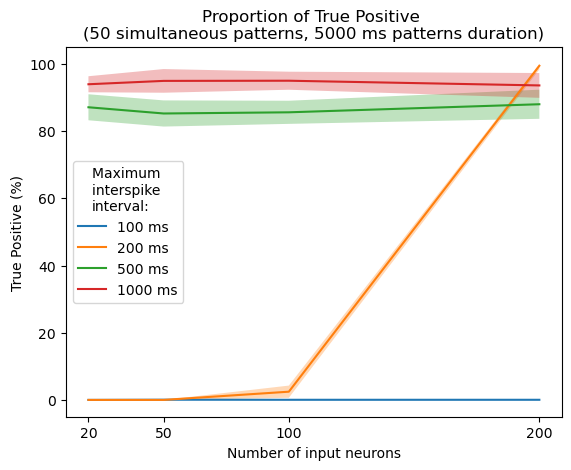

In [58]:
for key_num_pattern, _ in plot_result_dict_true_positive[next(iter(plot_result_dict_true_positive))].items():
    num_neuron_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_true_positive.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(max_time_interval)+' ms max insterspike interval'
        num_neuron_xaxis_list = num_neuron_xaxis.get(new_key,[])
        num_neuron_xaxis_list.append(num_input_neurons)
        num_neuron_xaxis[new_key] = num_neuron_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in num_neuron_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, max_time_interval_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(num_neuron_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(max_time_interval_key)+' ms')
        plt.fill_between(num_neuron_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Number of input neurons')
plt.ylabel('True Positive (%)')
plt.legend(title = 'Maximum \ninterspike \ninterval:', loc='center left')
plt.title('Proportion of True Positive \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([20,50,100,200])

([<matplotlib.axis.XTick at 0x1325dddf0>,
 [Text(20, 0, '20'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(200, 0, '200')])

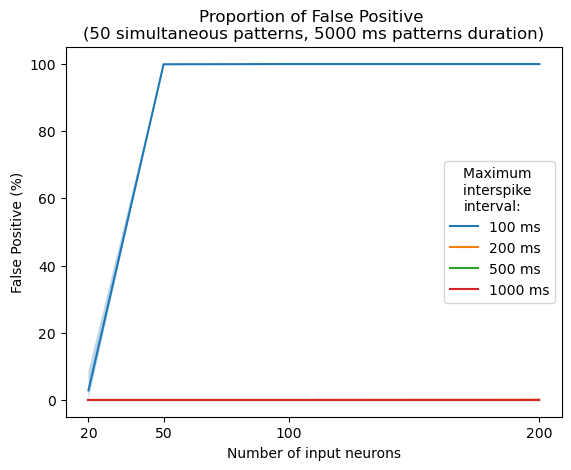

In [59]:
for key_num_pattern, _ in plot_result_dict_false_positive[next(iter(plot_result_dict_false_positive))].items():
    num_neuron_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_false_positive.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(max_time_interval)+' ms max insterspike interval'
        num_neuron_xaxis_list = num_neuron_xaxis.get(new_key,[])
        num_neuron_xaxis_list.append(num_input_neurons)
        num_neuron_xaxis[new_key] = num_neuron_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in num_neuron_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, max_time_interval_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(num_neuron_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(max_time_interval_key)+' ms')
        plt.fill_between(num_neuron_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Number of input neurons')
plt.ylabel('False Positive (%)')
plt.legend(title = 'Maximum \ninterspike \ninterval:', loc='center right')
plt.title('Proportion of False Positive \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([20,50,100,200])

([<matplotlib.axis.XTick at 0x132242360>,
 [Text(20, 0, '20'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(200, 0, '200')])

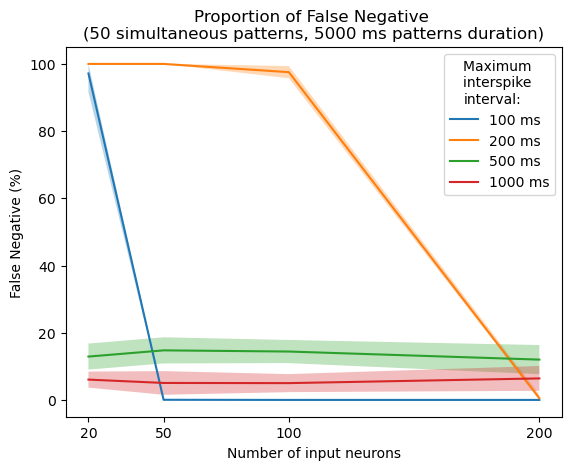

In [46]:
for key_num_pattern, _ in plot_result_dict_false_negative[next(iter(plot_result_dict_false_negative))].items():
    num_neuron_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_false_negative.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(max_time_interval)+' ms max insterspike interval'
        num_neuron_xaxis_list = num_neuron_xaxis.get(new_key,[])
        num_neuron_xaxis_list.append(num_input_neurons)
        num_neuron_xaxis[new_key] = num_neuron_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in num_neuron_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, max_time_interval_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(num_neuron_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(max_time_interval_key)+' ms')
        plt.fill_between(num_neuron_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Number of input neurons')
plt.ylabel('False Negative (%)')
plt.legend(title = 'Maximum \ninterspike \ninterval:', loc='upper right')
plt.title('Proportion of False Negative \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([20,50,100,200])

([<matplotlib.axis.XTick at 0x13261d790>,
 [Text(100, 0, '100'),
  Text(200, 0, '200'),
  Text(500, 0, '500'),
  Text(1000, 0, '1000')])

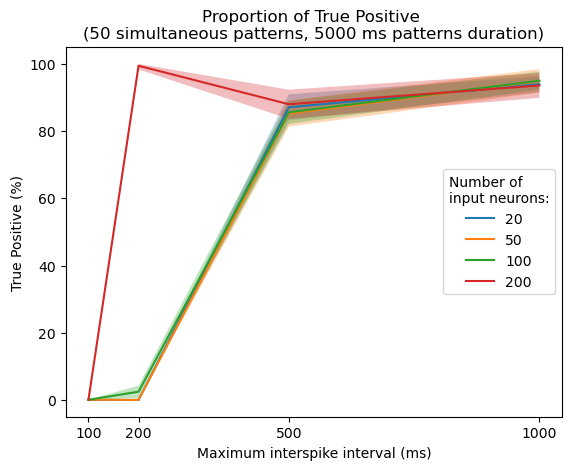

In [60]:
for key_num_pattern, _ in plot_result_dict_true_positive[next(iter(plot_result_dict_true_positive))].items():
    max_time_interval_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_true_positive.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(num_input_neurons)+' ms max insterspike interval'
        max_time_interval_xaxis_list = max_time_interval_xaxis.get(new_key,[])
        max_time_interval_xaxis_list.append(max_time_interval)
        max_time_interval_xaxis[new_key] = max_time_interval_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in max_time_interval_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, num_input_neurons_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(max_time_interval_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(num_input_neurons_key))
        plt.fill_between(max_time_interval_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Maximum interspike interval (ms)')
plt.ylabel('True Positive (%)')
plt.legend(title = 'Number of \ninput neurons:', loc='center right')
plt.title('Proportion of True Positive \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([100,200,500,1000])

([<matplotlib.axis.XTick at 0x1326e8140>,
 [Text(100, 0, '100'),
  Text(200, 0, '200'),
  Text(500, 0, '500'),
  Text(1000, 0, '1000')])

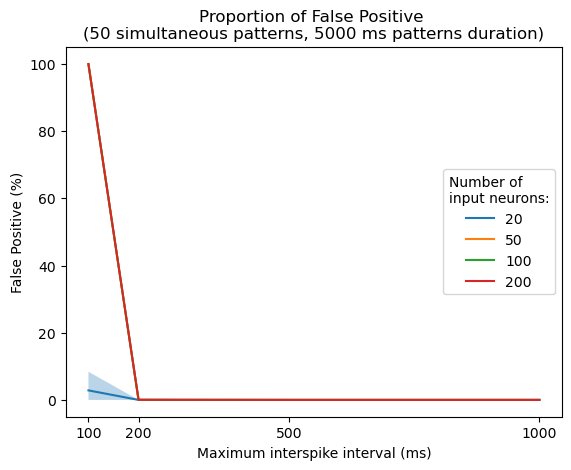

In [61]:
for key_num_pattern, _ in plot_result_dict_false_positive[next(iter(plot_result_dict_false_positive))].items():
    max_time_interval_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_false_positive.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(num_input_neurons)+' ms max insterspike interval'
        max_time_interval_xaxis_list = max_time_interval_xaxis.get(new_key,[])
        max_time_interval_xaxis_list.append(max_time_interval)
        max_time_interval_xaxis[new_key] = max_time_interval_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in max_time_interval_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, num_input_neurons_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(max_time_interval_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(num_input_neurons_key))
        plt.fill_between(max_time_interval_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Maximum interspike interval (ms)')
plt.ylabel('False Positive (%)')
plt.legend(title = 'Number of \ninput neurons:', loc='center right')
plt.title('Proportion of False Positive \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([100,200,500,1000])

([<matplotlib.axis.XTick at 0x132765b80>,
 [Text(100, 0, '100'),
  Text(200, 0, '200'),
  Text(500, 0, '500'),
  Text(1000, 0, '1000')])

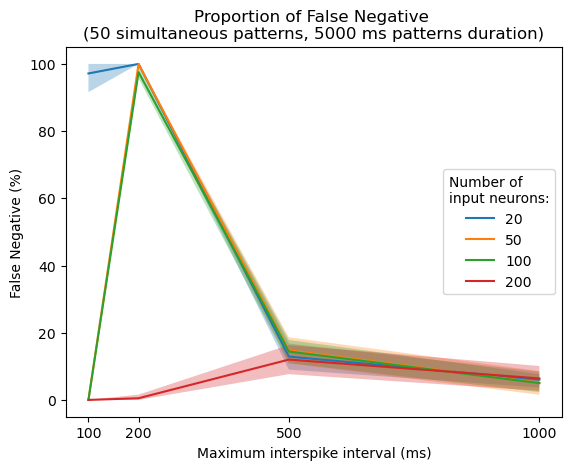

In [62]:
for key_num_pattern, _ in plot_result_dict_false_negative[next(iter(plot_result_dict_false_negative))].items():
    max_time_interval_xaxis = {}
    true_positive_yaxis_mean = {}
    true_positive_yaxis_mean_minus_std = {}
    true_positive_yaxis_mean_plus_std = {}
    for key, value in plot_result_dict_false_negative.items():
        num_input_neurons, pattern_duration, max_time_interval = [int(word) for word in key.split() if word.isdigit()]
        new_key = str(pattern_duration)+' ms duration, ' + str(key_num_pattern)+' patterns, '+ str(num_input_neurons)+' ms max insterspike interval'
        max_time_interval_xaxis_list = max_time_interval_xaxis.get(new_key,[])
        max_time_interval_xaxis_list.append(max_time_interval)
        max_time_interval_xaxis[new_key] = max_time_interval_xaxis_list
        true_positive_yaxis_mean_list = true_positive_yaxis_mean.get(new_key,[])
        true_positive_yaxis_mean_list.append(np.mean(value[key_num_pattern]))
        true_positive_yaxis_mean[new_key] = true_positive_yaxis_mean_list
        true_positive_yaxis_mean_minus_std_list = true_positive_yaxis_mean_minus_std.get(new_key,[])
        true_positive_yaxis_mean_minus_std_list.append(max(0, np.mean(value[key_num_pattern]) - np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_minus_std[new_key] = true_positive_yaxis_mean_minus_std_list
        true_positive_yaxis_mean_plus_std_list = true_positive_yaxis_mean_plus_std.get(new_key,[])
        true_positive_yaxis_mean_plus_std_list.append(min(100, np.mean(value[key_num_pattern]) + np.std(value[key_num_pattern])))
        true_positive_yaxis_mean_plus_std[new_key] = true_positive_yaxis_mean_plus_std_list
    for new_key, _ in max_time_interval_xaxis.items():
        [pattern_duration_simul, num_patterns_simul, num_input_neurons_key] = [int(word) for word in new_key.split() if word.isdigit()]
        plt.plot(max_time_interval_xaxis[new_key], true_positive_yaxis_mean[new_key], label = str(num_input_neurons_key))
        plt.fill_between(max_time_interval_xaxis[new_key], true_positive_yaxis_mean_minus_std[new_key], true_positive_yaxis_mean_plus_std[new_key], alpha=0.3)
plt.xlabel('Maximum interspike interval (ms)')
plt.ylabel('False Negative (%)')
plt.legend(title = 'Number of \ninput neurons:', loc='center right')
plt.title('Proportion of False Negative \n('+str(num_patterns_simul)+' simultaneous patterns, '+str(pattern_duration_simul)+ ' ms patterns duration)')
plt.ylim([-5,105])
plt.xticks([100,200,500,1000])